In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# ****Data Visualization****

In [19]:
import pandas as pd
import numpy as np

train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

print("head:")
print(train.head())
print("shape:")
print(train.shape)
print("info:")
print(train.info())
print("sum:")
print(train.isnull().sum())
print("dtype:")
print(train.dtypes)
train.select_dtypes(include="object").columns
train.select_dtypes(include=["int64","float64"]).columns

head:
                       created_date  post_id  emoticon_1  emoticon_2  \
0  2024-01-18 08:43:57.397508+00:00       73           0           0   
1  2024-03-24 21:43:11.490017+00:00       39           0           0   
2  2024-04-24 20:32:17.014931+00:00       31           0           1   
3  2023-05-28 22:00:14.214527+00:00       39           0           0   
4  2023-09-09 23:12:05.689498+00:00       39           0           0   

   emoticon_3  upvote  downvote  if_1  if_2 race religion gender  disability  \
0           0       0         1     0    10  NaN      NaN    NaN       False   
1           0       6         0     0     4  NaN      NaN    NaN       False   
2           1       0         0     0    10  NaN      NaN    NaN       False   
3           0       5         0     0    10  NaN      NaN    NaN       False   
4           0       0         0     0    10  NaN      NaN    NaN       False   

                                             comment  label  
0  She might be a 

Index(['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote',
       'downvote', 'if_1', 'if_2', 'label'],
      dtype='object')

In [20]:
train["label"].nunique()

4

In [21]:
train["label"].value_counts(normalize=True) * 100

label
0    57.663131
2    31.535354
1     8.039394
3     2.762121
Name: proportion, dtype: float64

In [22]:
train["upvote"].median()

1.0

In [23]:
train[["upvote","downvote","if_1","if_2"]].max()

upvote       201
downvote     107
if_1        1860
if_2        1833
dtype: int64

In [24]:
train["if_2"].min()

3

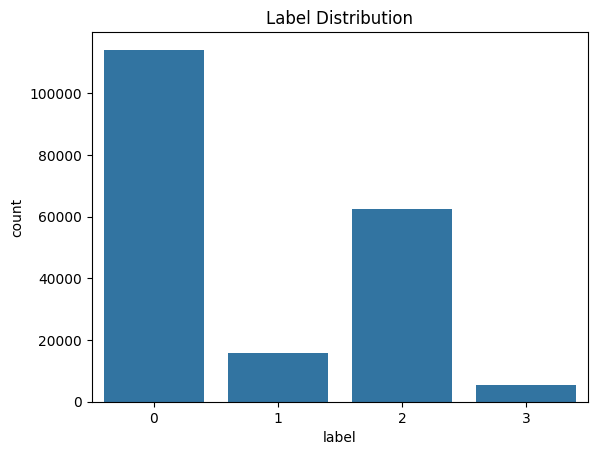

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="label", data=train)
plt.title("Label Distribution")
plt.show()

In [7]:
train[["upvote","downvote"]].describe()

,upvote,downvote
count,198000.000000,198000.000000
mean,2.607975,0.666394
std,5.054763,2.044335
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,0.000000
75%,3.000000,1.000000
max,201.000000,107.000000


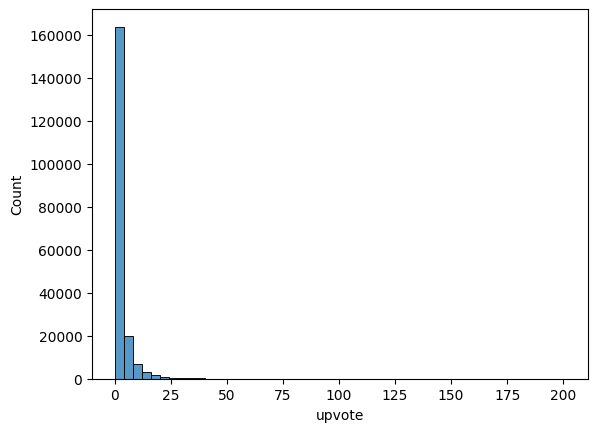

In [8]:
sns.histplot(train["upvote"], bins=50)
plt.show()

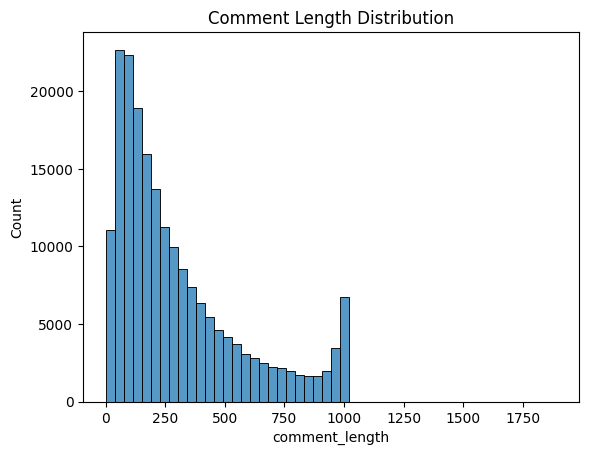

In [10]:
train["comment_length"] = train["comment"].fillna("").apply(len)

sns.histplot(train["comment_length"], bins=50)
plt.title("Comment Length Distribution")
plt.show()

Numerical: upvote, downvote, if_1, if_2

Binary/Categorical: emoticon_1, emoticon_2, emoticon_3, race, religion, gender, disability

Text: comment

Target: label

In [14]:
from sklearn.model_selection import train_test_split

train["comment"] = train["comment"].fillna("")
test["comment"] = test["comment"].fillna("")

X = train.drop("label", axis=1)
y = train["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_text = tfidf.fit_transform(X_train["comment"])
X_val_text = tfidf.transform(X_val["comment"])

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)

model.fit(X_train_text, y_train)

val_preds = model.predict(X_val_text)

accuracy_score(y_val, val_preds)

0.7790909090909091

In [17]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

train["comment"] = train["comment"].apply(clean_text)